In [1]:
import numpy as np
from plot import show_1D_profiles, show_diffractograms
import torch
from torch.utils.data import TensorDataset, DataLoader

data_path = "dataset/x_input/input_au.npy"
target = np.load("dataset/x_target/target_au.npy")


In [2]:
from unet import ResidualUNet
model_path = "runs/20260408_143837_batch_size=32_log_interval=200_lr=0.0001_model_params={'in_channels': 1, 'base_channels': 8, 'logspace': False, 'normalize': False, 'predict_background': True}_num_epochs=20/residual_unet_epoch14.pt"
model, params = ResidualUNet.load(model_path)

In [3]:
def process(model, data_path):
    data_original = np.load(data_path)
    data = data_original[:, None].astype(np.float32)
    data = torch.from_numpy(data)

    dataset = TensorDataset(data)
    dataloader = DataLoader(dataset, batch_size=100)

    model = model.cuda()
    outputs = []
    for batch in dataloader:
        b = batch[0].cuda()
        output, _ = model.predict(b)
        outputs.append(output)

    output = torch.cat(outputs).squeeze()

    return data_original, output.cpu().numpy()

In [4]:
def zero_spatial_edges(data, border_width=1):
    """
    Zeros the edges of an array with shape (..., H, W).
    Works for (C, H, W) and (B, C, H, W).
    """
    res = data.copy()
    w = border_width
    
    # Zero Top and Bottom
    res[..., :w, :] = 0      # All batches/channels, first 'w' rows
    res[..., -w:, :] = 0     # All batches/channels, last 'w' rows
    
    # Zero Left and Right
    res[..., :, :w] = 0      # All batches/channels, first 'w' columns
    res[..., :, -w:] = 0     # All batches/channels, last 'w' columns
    
    return res

In [5]:
data, output = process(model, data_path)

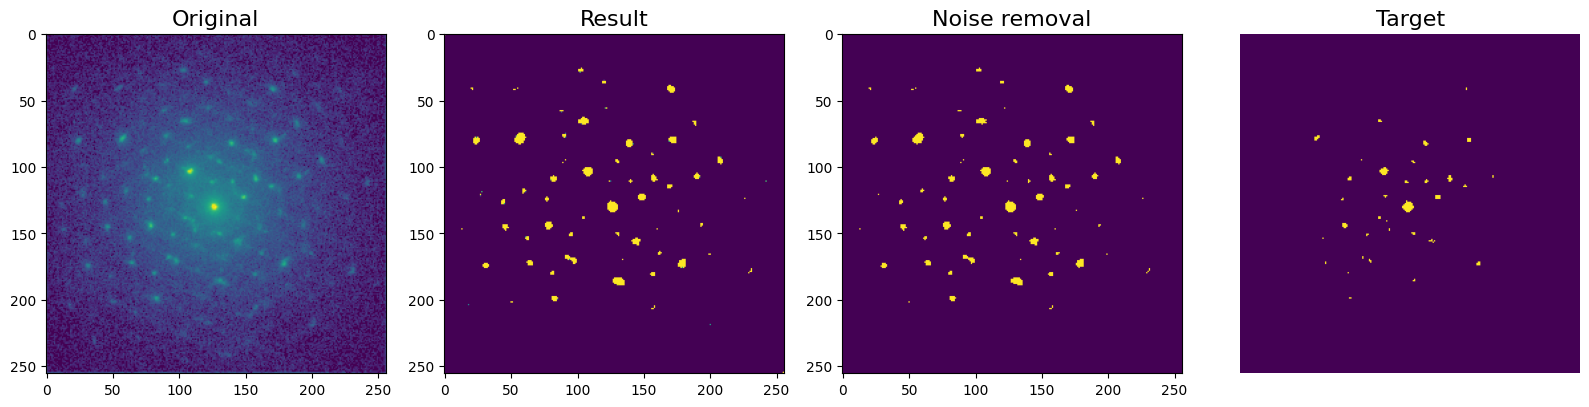

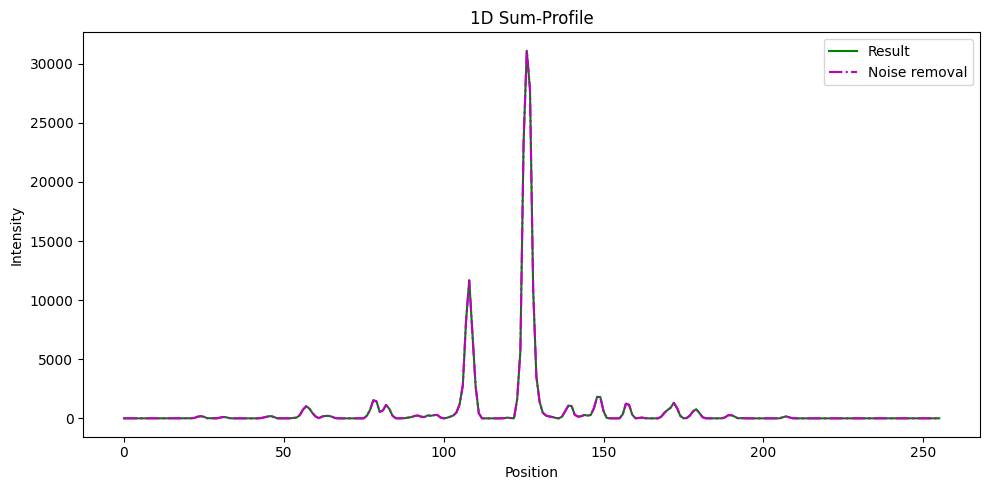

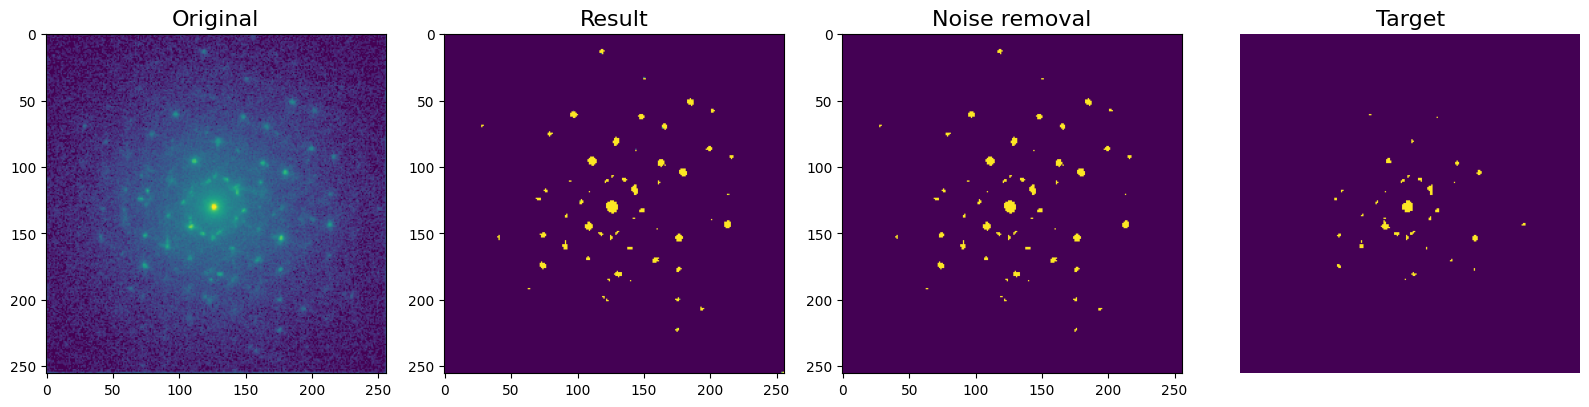

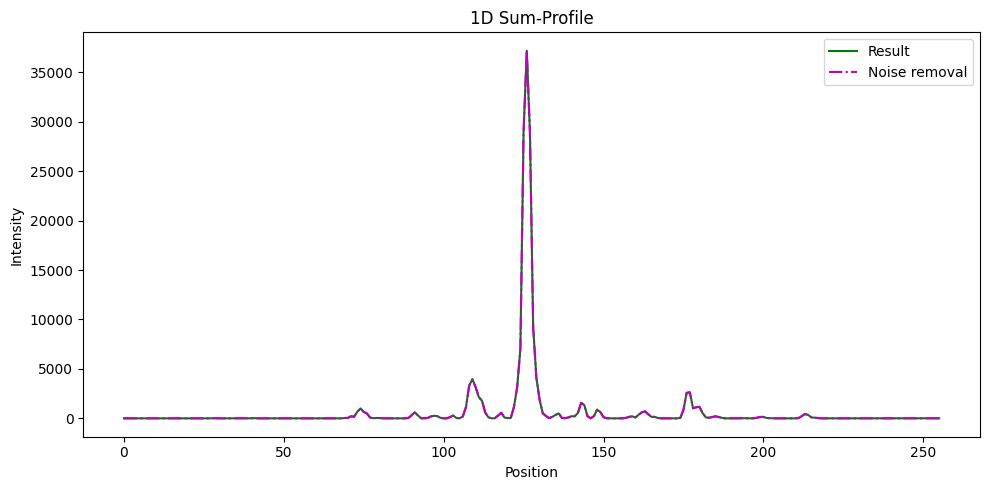

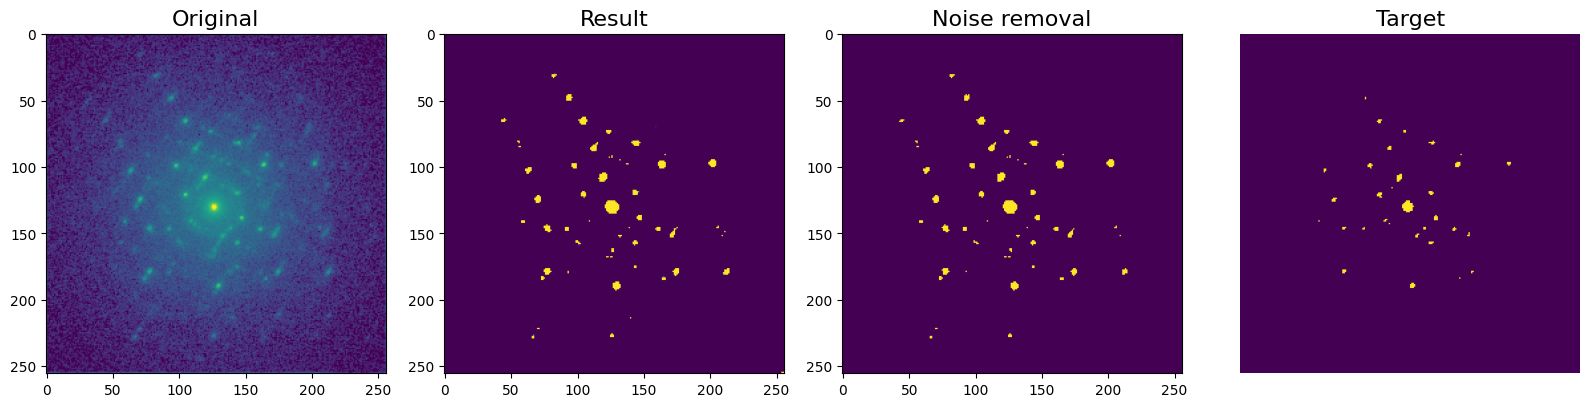

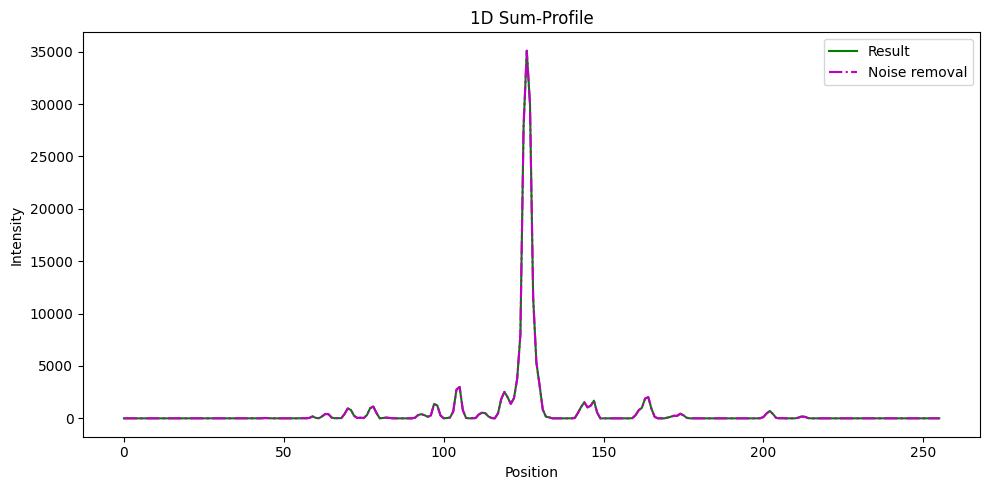

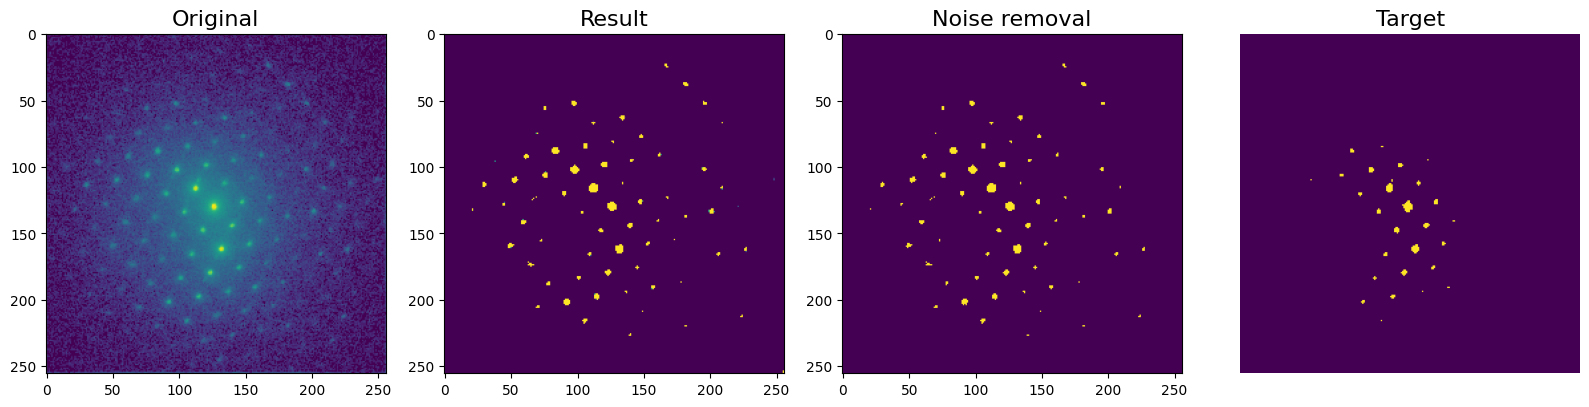

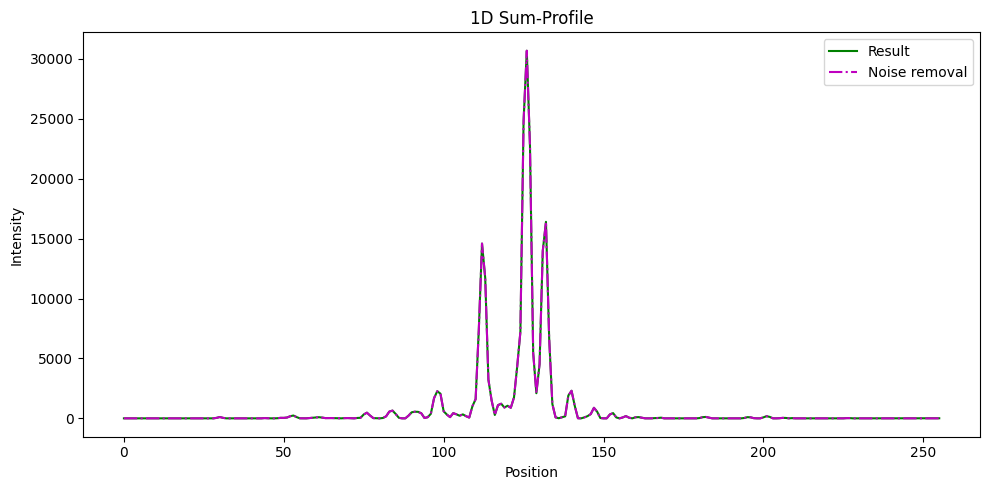

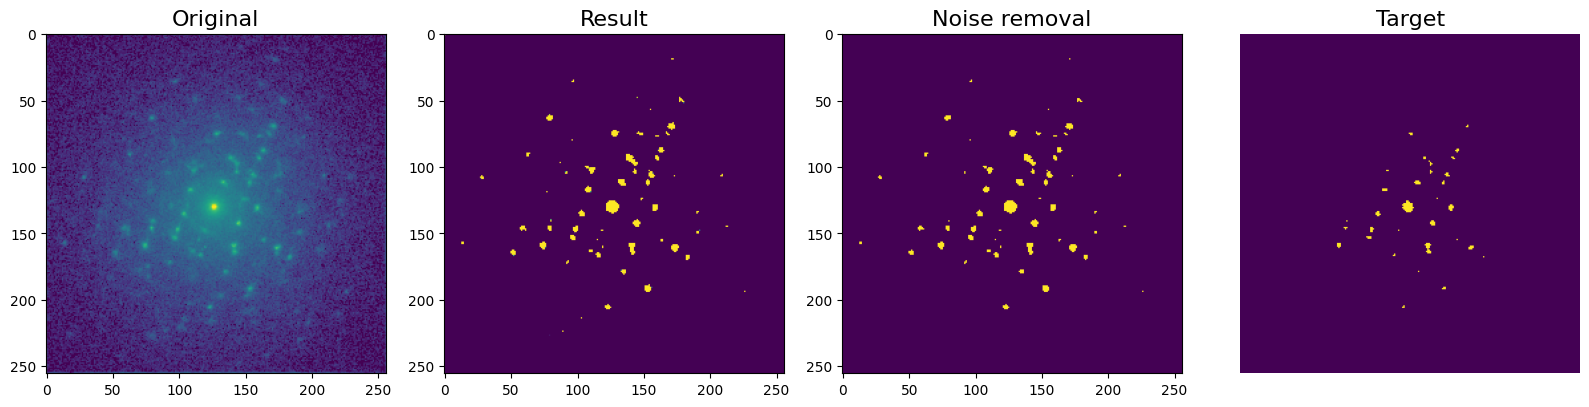

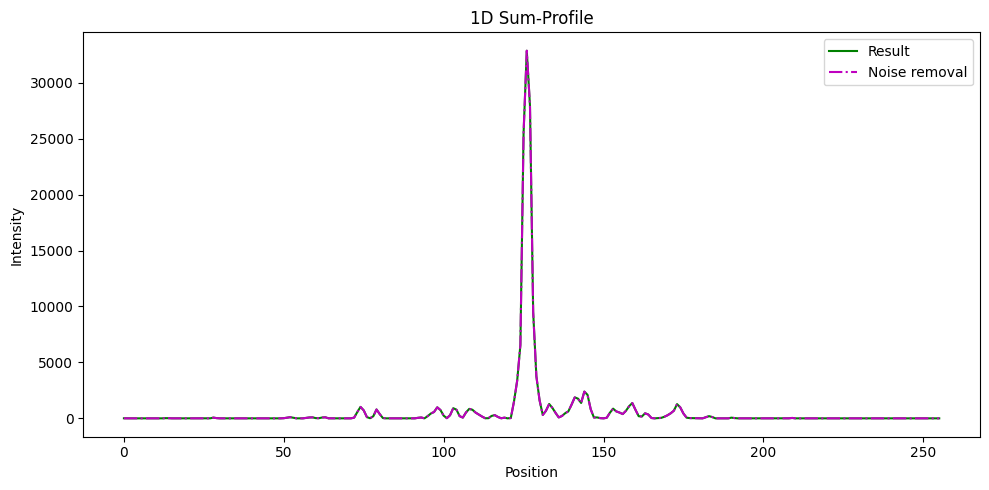

In [ ]:
for i in range(5):
    noise_rem = output[i].copy()
    thr = 2
    noise_rem[noise_rem<thr]=0
    noise_rem = zero_spatial_edges(noise_rem)
    show_diffractograms({
            "Original": data[i], 
            "Result": output[i],
            "Noise removal": noise_rem,
            "Target": target[i]
        }, 1)
    show_1D_profiles({
            "Result": (output[i], "green"), 
            "Noise removal": (noise_rem, "-.m")
        })